In [25]:
from ash import *

In [26]:
#Defining fragment
frag = Fragment(xyzfile="water.xyz", charge=0, mult=1)


--------------------------------------------------------------------------------
                                New ASH fragment                                
--------------------------------------------------------------------------------

ASH Fragment creation
Reading coordinates from XYZ file 'water.xyz' into fragment.
Creating/Updating fragment attributes...
Number of Atoms in fragment: 3
Formula: H2O1
Label: water
Charge: 0 Mult: 1

--------------------------------------------------------------------------------


In [27]:
xyz_list = [i for i in zip(frag.elems, frag.coords)]

lines = [str(len(xyz_list)), '']
for symbol, coords in xyz_list:
    line = f"{symbol} {coords[0]} {coords[1]} {coords[2]}"
    lines.append(line)

xyz_string = "\n".join(lines)
print(xyz_string)

3

O 0.0 0.0 0.0
H 0.0 0.758081 -0.635808
H -0.0 -0.758081 -0.635808


In [28]:
BASIS = '6-31g'
XC = 'pbe0'

In [29]:
nbed_theory = NbedTheory(
    geometry=xyz_string,
    n_active_atoms=1,
    basis=BASIS,
    xc_functional=XC,
    projector='mu',
    localization='spade'
)



                     #####################################                      
                     #                                   #                      
                     #     NbedTheory initialization     #                      
                     #                                   #                      
                     #####################################                      


In [30]:
sp = Singlepoint(theory=nbed_theory, fragment=frag)



                        ################################                        
                        #                              #                        
                        #     Singlepoint function     #                        
                        #                              #                        
                        ################################                        
 Charge/mult was not provided to Singlepoint 
 Fragment contains charge/mult information: Charge: 0 Mult: 1  Using this. 

Doing single-point Energy job on fragment. Formula: H2O1 Label: water 
Charge: 0 Mult: 1
  ------------RUNNING Nbed INTERFACE------------- 
Job label: None
Energy:  -76.18922592115774

-----------------------------------------------------------------
Time to calculate step (Singlepoint): 0.168 seconds, 0.0 minutes.
-----------------------------------------------------------------

Writing to disk defined attributes of ASH_Results dataclass
Results object data:
label

/Users/tom/Documents/ucl/projects/ash-fork/.venv/lib/python3.11/site-packages/nbed/driver.py:539: RuntimeWarning: divide by zero encountered in matmul
  env_projector_alpha = s_mat @ self.localized_system.dm_enviro @ s_mat
/Users/tom/Documents/ucl/projects/ash-fork/.venv/lib/python3.11/site-packages/nbed/driver.py:539: RuntimeWarning: overflow encountered in matmul
  env_projector_alpha = s_mat @ self.localized_system.dm_enviro @ s_mat
/Users/tom/Documents/ucl/projects/ash-fork/.venv/lib/python3.11/site-packages/nbed/driver.py:539: RuntimeWarning: invalid value encountered in matmul
  env_projector_alpha = s_mat @ self.localized_system.dm_enviro @ s_mat
Initialize <pyscf.gto.mole.Mole object at 0x308840310> in <pyscf.dft.rks.RKS object at 0x307ff7110>
/Users/tom/Documents/ucl/projects/ash-fork/.venv/lib/python3.11/site-packages/nbed/localizers/spade.py:159: RuntimeWarning: divide by zero encountered in matmul
  left = np.linalg.inv(projected_overlap) @ overlap_two_basis @ effective_vir

In [31]:
sp.energy

np.float64(-76.18922592115774)

In [32]:
from nbed.driver import NbedDriver

In [33]:
driver = NbedDriver(
    geometry=xyz_string,
    n_active_atoms=1,
    basis=BASIS,
    xc_functional=XC,
    projector='mu',
    localization='spade'
)

Initialize <pyscf.gto.mole.Mole object at 0x3088405d0> in <pyscf.dft.rks.RKS object at 0x304348510>


In [34]:
driver._global_ks.nuc_grad_method()

In [35]:
proj_data = driver._mu

In [36]:
emb_corr = (
    driver.e_env
    + driver.two_e_cross
    - proj_data["correction"]
    - proj_data["beta_correction"]
)

emb_ccsd, _ = driver._run_emb_CCSD(driver.embedded_scf)
emb_ccsdt_energy = emb_ccsd.e_tot + emb_ccsd.ccsd_t()

print(emb_ccsdt_energy + emb_corr)

-76.18922592115774


In [37]:
assert sp.energy == emb_ccsdt_energy + emb_corr, "Ash singlepoint energy does not match the same calculated energy from NbedDriver."

In [38]:
import pyscf

In [39]:
mol_obj = pyscf.M(
    atom='water.xyz',
    basis=BASIS,
    charge=0,
    spin=0,
    verbose=0
)

In [40]:
rhf_obj = pyscf.scf.RHF(mol_obj).run()

In [41]:
cc_obj = pyscf.cc.CCSD(rhf_obj).run()

In [42]:
ccsd_e = cc_obj.e_tot + cc_obj.ccsd_t()

In [43]:
dft_obj = pyscf.dft.RKS(mol_obj)
dft_obj.xc = XC
dft_obj.run()

In [44]:
import matplotlib.pyplot as plt

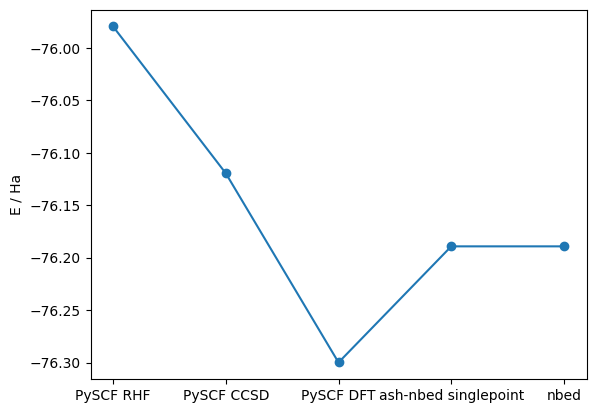

In [45]:
x = np.arange(5)

plt.plot(x, [rhf_obj.e_tot, ccsd_e, dft_obj.e_tot, sp.energy, emb_ccsdt_energy + emb_corr], 'o-')
plt.xticks(x, ['PySCF RHF', 'PySCF CCSD', 'PySCF DFT', 'ash-nbed singlepoint', 'nbed'])
plt.ylabel('E / Ha')

plt.show()